
Raster files found: 26

Cropland mask loaded & reprojected: cropland_mask.tif
  Mask shape       : (531, 679)  (matches LST rasters)
  Cropland pixels  : 84,711
  Non-cropland     : 275,838

Reading LST_SEP_2000.tif

Reading LST_SEP_2001.tif

Reading LST_SEP_2002.tif

Reading LST_SEP_2003.tif

Reading LST_SEP_2004.tif

Reading LST_SEP_2005.tif

Reading LST_SEP_2006.tif

Reading LST_SEP_2007.tif

Reading LST_SEP_2008.tif

Reading LST_SEP_2009.tif

Reading LST_SEP_2010.tif

Reading LST_SEP_2011.tif

Reading LST_SEP_2012.tif

Reading LST_SEP_2013.tif

Reading LST_SEP_2014.tif

Reading LST_SEP_2015.tif

Reading LST_SEP_2016.tif

Reading LST_SEP_2017.tif

Reading LST_SEP_2018.tif

Reading LST_SEP_2019.tif

Reading LST_SEP_2020.tif

Reading LST_SEP_2021.tif

Reading LST_SEP_2022.tif

Reading LST_SEP_2023.tif

Reading LST_SEP_2024.tif

Reading LST_SEP_2025.tif

Stack shape: (26, 531, 679)

Cropland mask applied to LST stack.

Baseline years used: [2000 2001 2002 2003 2004 2005 2006 2007 2008

/tmp/ipykernel_162138/1085683434.py:163: RuntimeWarning: All-NaN slice encountered
  lst_min = np.nanmin(baseline_stack, axis=0)
/tmp/ipykernel_162138/1085683434.py:164: RuntimeWarning: All-NaN slice encountered
  lst_max = np.nanmax(baseline_stack, axis=0)



PNG saved: /home/root_1/Documents/CDL/repos/dri/modelling/outputs/TCI_SEP_2024.png


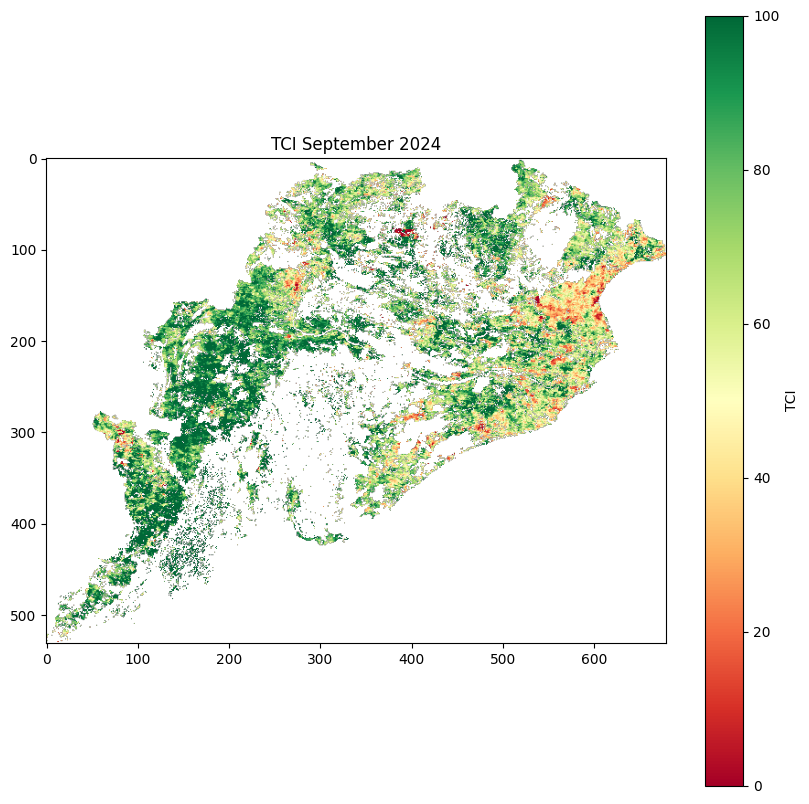


DONE.


In [1]:
# =============================================================================
# PIXELWISE TCI MODELLING
# SEPTEMBER TCI
# BASELINE: 2000–2020
# TARGET: 2024
# =============================================================================

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import rasterio
from rasterio.warp import Resampling, reproject


# =============================================================================
# PATHS
# =============================================================================

BASE_DIR = Path.cwd()
INPUT_DIR = BASE_DIR / "outputs" / "rasters"
OUTPUT_DIR = BASE_DIR / "outputs"
CROPLAND_MASK_PATH = BASE_DIR / "cropland_mask.tif"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


# =============================================================================
# PARAMETERS
# =============================================================================

BASELINE_START = 2000
BASELINE_END = 2020
TARGET_YEAR = 2024


# =============================================================================
# FIND RASTERS
# =============================================================================

raster_files = sorted(INPUT_DIR.glob("LST_SEP_*.tif"))
print(f"\nRaster files found: {len(raster_files)}")

if len(raster_files) == 0:
    raise FileNotFoundError("No raster files found.")


# =============================================================================
# LOAD CROPLAND MASK
# Cropland pixels: mask value < 2
# Mask is reprojected/resampled to exactly match the LST raster grid
# Non-cropland pixels are excluded from TCI computation
# =============================================================================

if not CROPLAND_MASK_PATH.exists():
    raise FileNotFoundError(f"Cropland mask not found: {CROPLAND_MASK_PATH}")

# Read reference grid properties from the first LST raster
with rasterio.open(raster_files[0]) as ref:
    ref_crs = ref.crs
    ref_transform = ref.transform
    ref_width = ref.width
    ref_height = ref.height

# Reproject cropland mask onto the LST raster grid (nearest-neighbour for labels)
with rasterio.open(CROPLAND_MASK_PATH) as src:
    cropland_mask_raw = np.empty((ref_height, ref_width), dtype=np.float32)
    reproject(
        source=rasterio.band(src, 1),
        destination=cropland_mask_raw,
        src_transform=src.transform,
        src_crs=src.crs,
        dst_transform=ref_transform,
        dst_crs=ref_crs,
        resampling=Resampling.nearest,
    )
    mask_nodata = src.nodata
    if mask_nodata is not None:
        cropland_mask_raw[cropland_mask_raw == mask_nodata] = np.nan

# Boolean array: True where pixel IS cropland (value < 2)
cropland = cropland_mask_raw < 2

print(f"\nCropland mask loaded & reprojected: {CROPLAND_MASK_PATH.name}")
print(f"  Mask shape       : {cropland_mask_raw.shape}  (matches LST rasters)")
print(f"  Cropland pixels  : {cropland.sum():,}")
print(f"  Non-cropland     : {(~cropland).sum():,}")


# =============================================================================
# READ RASTERS
# =============================================================================

years = []
arrays = []
meta = None

for f in raster_files:
    year = int(f.stem.split("_")[-1])

    print(f"\nReading {f.name}")

    with rasterio.open(f) as src:
        arr = src.read(1).astype(np.float32)
        arr[arr < -100] = np.nan

        arrays.append(arr)
        years.append(year)

        if meta is None:
            meta = src.meta.copy()


# =============================================================================
# STACK
# =============================================================================

stack = np.stack(arrays, axis=0)
years = np.array(years)

print(f"\nStack shape: {stack.shape}")


# =============================================================================
# APPLY CROPLAND MASK TO STACK
# Non-cropland pixels set to NaN so they are excluded from TCI computation
# =============================================================================

stack[:, ~cropland] = np.nan

print("\nCropland mask applied to LST stack.")


# =============================================================================
# BASELINE STACK
# =============================================================================

baseline_mask = (years >= BASELINE_START) & (years <= BASELINE_END)
baseline_stack = stack[baseline_mask]

print(f"\nBaseline years used: {years[baseline_mask]}")


# =============================================================================
# TARGET YEAR
# =============================================================================

target_index = np.where(years == TARGET_YEAR)[0]

if len(target_index) == 0:
    raise ValueError(f"{TARGET_YEAR} raster not found.")

target_index = target_index[0]
target_lst = stack[target_index]


# =============================================================================
# CLIMATOLOGY
# =============================================================================

print("\nComputing climatology...")

lst_min = np.nanmin(baseline_stack, axis=0)
lst_max = np.nanmax(baseline_stack, axis=0)


# =============================================================================
# TCI COMPUTATION
# =============================================================================

print("\nComputing TCI...")

denominator = lst_max - lst_min
denominator[denominator < 0.001] = np.nan

tci = 100 * ((lst_max - target_lst) / denominator)
tci = np.clip(tci, 0, 100)


# =============================================================================
# TCI STATISTICS (cropland pixels only)
# =============================================================================

print("\nTCI Statistics (cropland pixels only)")
tci_cropland = tci[cropland]
tci_cropland = tci_cropland[np.isfinite(tci_cropland)]
print(f"  MIN  = {tci_cropland.min():.4f}")
print(f"  MAX  = {tci_cropland.max():.4f}")
print(f"  MEAN = {tci_cropland.mean():.4f}")


# =============================================================================
# SAVE RASTER
# =============================================================================

meta.update({
    "dtype": "float32",
    "count": 1,
    "compress": "lzw",
    "nodata": np.nan,
})

output_raster = OUTPUT_DIR / f"TCI_SEP_{TARGET_YEAR}.tif"

with rasterio.open(output_raster, "w", **meta) as dst:
    dst.write(tci.astype(np.float32), 1)

print(f"\nRaster saved: {output_raster}")


# =============================================================================
# QUICKLOOK PNG
# =============================================================================

fig, ax = plt.subplots(figsize=(10, 10))
im = ax.imshow(tci, cmap="RdYlGn", vmin=0, vmax=100)
fig.colorbar(im, ax=ax, label="TCI")
ax.set_title(f"TCI September {TARGET_YEAR}")

png_out = OUTPUT_DIR / f"TCI_SEP_{TARGET_YEAR}.png"
fig.savefig(png_out, dpi=300, bbox_inches="tight")
print(f"\nPNG saved: {png_out}")

plt.show()

print("\nDONE.")


CSV saved: districtwise_tci.csv


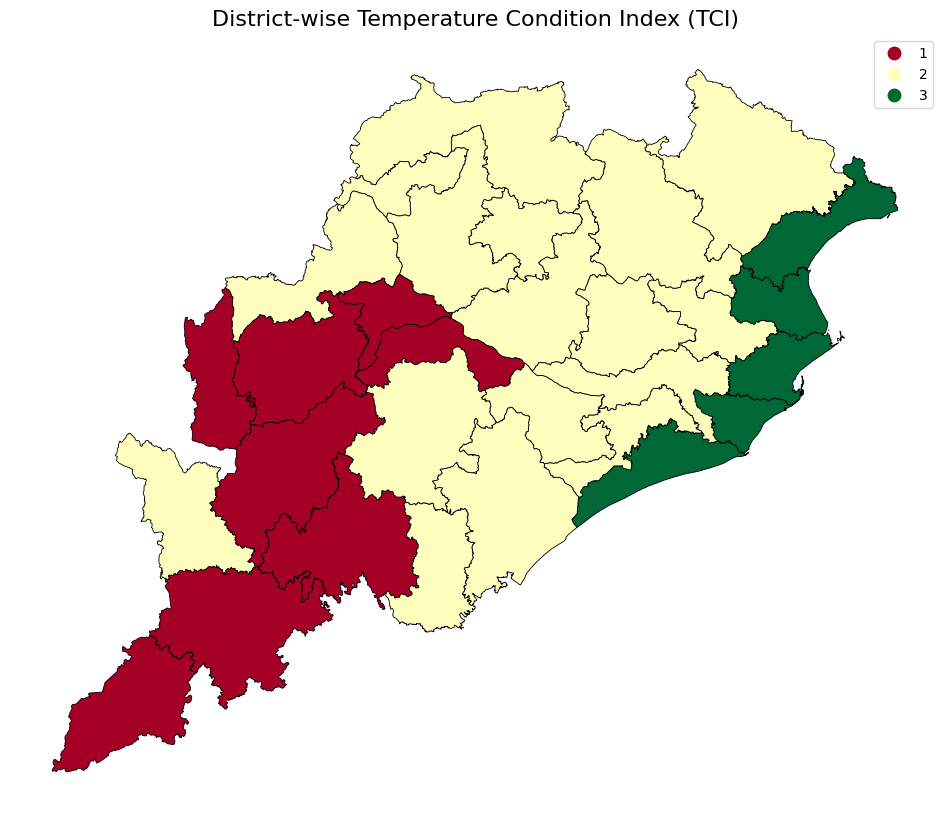

Map image saved: districtwise_tci_map.png

District-wise TCI Results:

            dtname   TCI_mean TCI_Class
0          Koraput  91.856884         1
1       Sundargarh  67.462140         2
2       Malkangiri  80.407981         1
3       Mayurbhanj  67.833865         2
4        Baleshwar  52.298670         3
5          Deogarh  78.467387         2
6           Anugul  73.597128         2
7      Nabarangpur  76.096243         2
8          Jajapur  65.233215         2
9       Jharsuguda  70.892522         2
10      Kendrapara  59.441159         3
11            Puri  59.795089         3
12       Kalahandi  88.901418         1
13        Nayagarh  64.170556         2
14        Rayagada  82.783138         1
15         Bargarh  75.529074         2
16         Bhadrak  49.471487         3
17           Boudh  85.041533         1
18        Gajapati  77.645100         2
19         Khordha  73.821558         2
20          Ganjam  67.218260         2
21        Balangir  89.643535         1
22  Jagat

In [6]:
# =============================================================================
# DISTRICT-WISE TCI CHOROPLETH
# CSV + IMAGE OUTPUT
# =============================================================================

# INSTALL
# pip install rasterio geopandas rasterstats matplotlib pandas

import rasterio
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
from rasterstats import zonal_stats

# =============================================================================
# INPUT FILES
# =============================================================================

tci_raster = "outputs/TCI_SEP_2024.tif"
districts_file = "district.geojson"

# OUTPUTS
csv_output = "districtwise_tci.csv"
image_output = "districtwise_tci_map.png"

# =============================================================================
# LOAD DISTRICTS
# =============================================================================

districts = gpd.read_file(districts_file)

# =============================================================================
# MATCH CRS
# =============================================================================

with rasterio.open(tci_raster) as src:
    raster_crs = src.crs

districts = districts.to_crs(raster_crs)

# =============================================================================
# DISTRICT-WISE MEAN TCI
# =============================================================================

stats = zonal_stats(
    districts,
    tci_raster,
    stats=["mean"],
    nodata=-9999
)

districts["TCI_mean"] = [x["mean"] for x in stats]

# =============================================================================
# TCI CLASSIFICATION
# =============================================================================

def classify_tci(tci):

    if tci < 20:
        return "5"

    elif tci < 40:
        return "4"

    elif tci < 60:
        return "3"

    elif tci < 80:
        return "2"

    else:
        return "1"

districts["TCI_Class"] = districts["TCI_mean"].apply(classify_tci)

# =============================================================================
# EXPORT CSV
# =============================================================================

# Replace DISTRICT_NAME with your actual district column
output_df = districts[
    ["dtname", "TCI_mean", "TCI_Class"]
]

output_df.to_csv(csv_output, index=False)

print(f"\nCSV saved: {csv_output}")

# =============================================================================
# SAVE CHOROPLETH IMAGE
# =============================================================================

fig, ax = plt.subplots(figsize=(12, 12))

districts.plot(
    column="TCI_Class",
    categorical=True,
    legend=True,
    cmap="RdYlGn",
    linewidth=0.6,
    edgecolor="black",
    ax=ax
)

ax.set_title(
    "District-wise Temperature Condition Index (TCI)",
    fontsize=16
)

ax.axis("off")

plt.savefig(
    image_output,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(f"Map image saved: {image_output}")

# =============================================================================
# PRINT RESULTS
# =============================================================================

print("\nDistrict-wise TCI Results:\n")

print(output_df)

In [ ]:
timescale tci

In [7]:
# =============================================================================
# PIXELWISE TCI MODELLING (BATCH VERSION - NO MASK)
# MULTI-YEAR SEPTEMBER TCI (ALL RASTERS)
# BASELINE: 2000–2020
# OUTPUT: ALL YEARS (~25 RASTERS)
# =============================================================================

from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import rasterio

# =============================================================================
# PATHS
# =============================================================================

BASE_DIR = Path.cwd()
INPUT_DIR = BASE_DIR / "outputs" / "rasters"
OUTPUT_DIR = BASE_DIR / "outputs" / "tci_timeseries"

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# =============================================================================
# PARAMETERS
# =============================================================================

BASELINE_START = 2000
BASELINE_END = 2020

# =============================================================================
# FIND RASTERS
# =============================================================================

raster_files = sorted(INPUT_DIR.glob("LST_SEP_*.tif"))
print(f"\nRaster files found: {len(raster_files)}")

if len(raster_files) == 0:
    raise FileNotFoundError("No raster files found.")

# =============================================================================
# READ RASTERS
# =============================================================================

years = []
arrays = []
meta = None

for f in raster_files:
    year = int(f.stem.split("_")[-1])
    print(f"Reading {f.name}")

    with rasterio.open(f) as src:
        arr = src.read(1).astype(np.float32)

        # remove extreme invalid values
        arr[arr < -100] = np.nan

        arrays.append(arr)
        years.append(year)

        if meta is None:
            meta = src.meta.copy()

stack = np.stack(arrays, axis=0)
years = np.array(years)

print(f"\nStack shape: {stack.shape}")

# =============================================================================
# BASELINE SELECTION
# =============================================================================

baseline_mask = (years >= BASELINE_START) & (years <= BASELINE_END)
baseline_stack = stack[baseline_mask]

print(f"\nBaseline years: {years[baseline_mask]}")

# =============================================================================
# CLIMATOLOGY
# =============================================================================

print("\nComputing climatology...")

lst_min = np.nanmin(baseline_stack, axis=0)
lst_max = np.nanmax(baseline_stack, axis=0)

denominator = lst_max - lst_min
denominator[denominator < 0.001] = np.nan

# =============================================================================
# COMPUTE TCI FOR ALL YEARS
# =============================================================================

print("\nComputing TCI for all years...")

for i, year in enumerate(years):

    tci = 100 * ((lst_max - stack[i]) / denominator)
    tci = np.clip(tci, 0, 100)

    print(f"\nYear {year}")
    print(f"  MIN  = {np.nanmin(tci):.2f}")
    print(f"  MAX  = {np.nanmax(tci):.2f}")
    print(f"  MEAN = {np.nanmean(tci):.2f}")

    # save raster
    meta.update({
        "dtype": "float32",
        "count": 1,
        "compress": "lzw",
        "nodata": np.nan,
    })

    out_raster = OUTPUT_DIR / f"TCI_SEP_{year}.tif"

    with rasterio.open(out_raster, "w", **meta) as dst:
        dst.write(tci.astype(np.float32), 1)

    # quicklook
    fig, ax = plt.subplots(figsize=(8, 8))
    im = ax.imshow(tci, cmap="RdYlGn", vmin=0, vmax=100)
    fig.colorbar(im, ax=ax, label="TCI")
    ax.set_title(f"TCI September {year}")

    png_out = OUTPUT_DIR / f"TCI_SEP_{year}.png"
    fig.savefig(png_out, dpi=200, bbox_inches="tight")
    plt.close(fig)

print("\nDONE: All TCI rasters generated (no mask).")


Raster files found: 26
Reading LST_SEP_2000.tif
Reading LST_SEP_2001.tif
Reading LST_SEP_2002.tif
Reading LST_SEP_2003.tif
Reading LST_SEP_2004.tif
Reading LST_SEP_2005.tif
Reading LST_SEP_2006.tif
Reading LST_SEP_2007.tif
Reading LST_SEP_2008.tif
Reading LST_SEP_2009.tif
Reading LST_SEP_2010.tif
Reading LST_SEP_2011.tif
Reading LST_SEP_2012.tif
Reading LST_SEP_2013.tif
Reading LST_SEP_2014.tif
Reading LST_SEP_2015.tif
Reading LST_SEP_2016.tif
Reading LST_SEP_2017.tif
Reading LST_SEP_2018.tif
Reading LST_SEP_2019.tif
Reading LST_SEP_2020.tif
Reading LST_SEP_2021.tif
Reading LST_SEP_2022.tif
Reading LST_SEP_2023.tif
Reading LST_SEP_2024.tif
Reading LST_SEP_2025.tif

Stack shape: (26, 531, 679)

Baseline years: [2000 2001 2002 2003 2004 2005 2006 2007 2008 2009 2010 2011 2012 2013
 2014 2015 2016 2017 2018 2019 2020]

Computing climatology...

Computing TCI for all years...

Year 2000
  MIN  = 0.00
  MAX  = 100.00
  MEAN = 41.05


/tmp/ipykernel_162138/3503889696.py:84: RuntimeWarning: All-NaN slice encountered
  lst_min = np.nanmin(baseline_stack, axis=0)
/tmp/ipykernel_162138/3503889696.py:85: RuntimeWarning: All-NaN slice encountered
  lst_max = np.nanmax(baseline_stack, axis=0)



Year 2001
  MIN  = 0.00
  MAX  = 100.00
  MEAN = 37.10

Year 2002
  MIN  = 0.00
  MAX  = 100.00
  MEAN = 29.40

Year 2003
  MIN  = 0.00
  MAX  = 100.00
  MEAN = 57.47

Year 2004
  MIN  = 0.00
  MAX  = 100.00
  MEAN = 40.57

Year 2005
  MIN  = 0.00
  MAX  = 100.00
  MEAN = 58.40

Year 2006
  MIN  = 0.00
  MAX  = 100.00
  MEAN = 54.74

Year 2007
  MIN  = 0.00
  MAX  = 100.00
  MEAN = 62.53

Year 2008
  MIN  = 0.00
  MAX  = 100.00
  MEAN = 61.28

Year 2009
  MIN  = 0.00
  MAX  = 100.00
  MEAN = 39.85

Year 2010
  MIN  = 0.00
  MAX  = 100.00
  MEAN = 42.79

Year 2011
  MIN  = 0.00
  MAX  = 100.00
  MEAN = 45.51

Year 2012
  MIN  = 0.00
  MAX  = 100.00
  MEAN = 49.42

Year 2013
  MIN  = 0.00
  MAX  = 100.00
  MEAN = 51.29

Year 2014
  MIN  = 0.00
  MAX  = 100.00
  MEAN = 39.95

Year 2015
  MIN  = 0.00
  MAX  = 100.00
  MEAN = 41.93

Year 2016
  MIN  = 0.00
  MAX  = 100.00
  MEAN = 62.54

Year 2017
  MIN  = 0.00
  MAX  = 100.00
  MEAN = 40.72

Year 2018
  MIN  = 0.00
  MAX  = 100.00
  MEAN 